In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [52]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

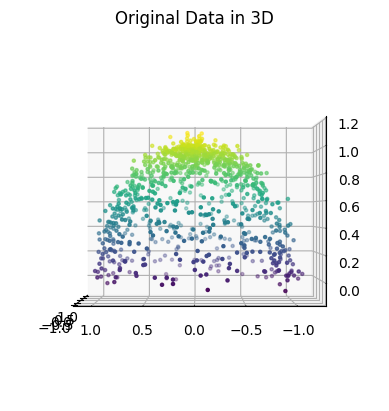

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

model_path = "models/conformal_autoencoder_half_sphere.pth"
optimizer_path = "models/conformal_autoencoder_half_sphere_optimizer.pth"

In [6]:
from metrics import conformality_angle2_loss

In [16]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = ConformalAutoencoder(encoder, decoder, lambda_conf=0.1).to(device)
conformal_autoencoder.conformality_loss = conformality_angle2_loss
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

Epoch [100/1000], Loss: 0.00208172, Reconstruction Loss: 0.00119854, Conformal Loss: 0.00883179
Epoch [100/1000], Validation Loss: 0.00213626, Reconstruction Loss: 0.00124887, Conformal Loss: 0.00887391
Epoch [200/1000], Loss: 0.00183448, Reconstruction Loss: 0.00111690, Conformal Loss: 0.00717578
Epoch [200/1000], Validation Loss: 0.00174679, Reconstruction Loss: 0.00114353, Conformal Loss: 0.00603263
Epoch [300/1000], Loss: 0.00155693, Reconstruction Loss: 0.00098155, Conformal Loss: 0.00575379
Epoch [300/1000], Validation Loss: 0.00163205, Reconstruction Loss: 0.00108896, Conformal Loss: 0.00543090
Epoch [400/1000], Loss: 0.00141019, Reconstruction Loss: 0.00092479, Conformal Loss: 0.00485400
Epoch [400/1000], Validation Loss: 0.00155846, Reconstruction Loss: 0.00101841, Conformal Loss: 0.00540053
Epoch [500/1000], Loss: 0.00137088, Reconstruction Loss: 0.00090079, Conformal Loss: 0.00470093
Epoch [500/1000], Validation Loss: 0.00146290, Reconstruction Loss: 0.00098988, Conformal Lo

In [7]:
conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_half_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_half_sphere_optimizer.pth


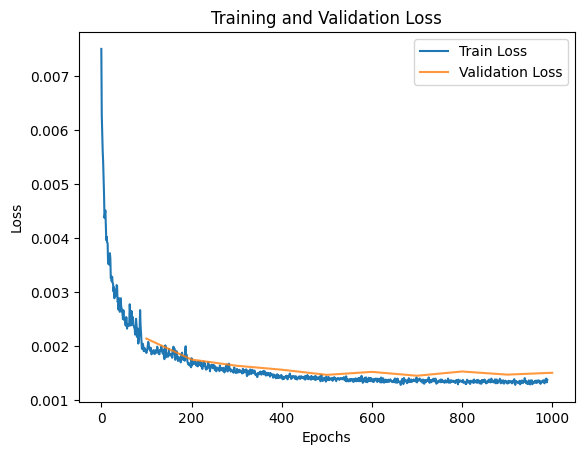

In [17]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

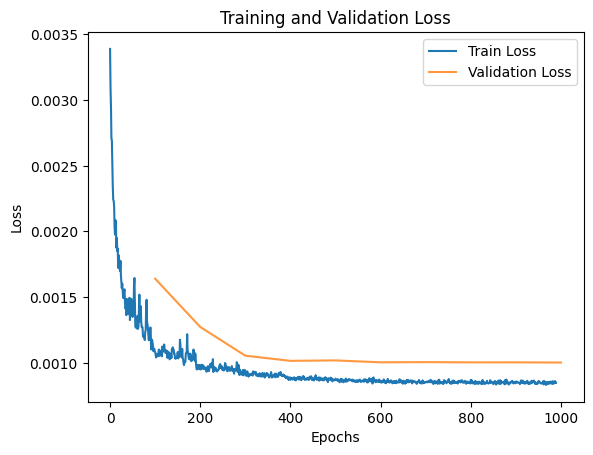

In [8]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

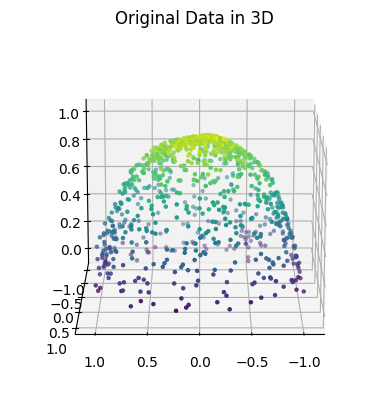

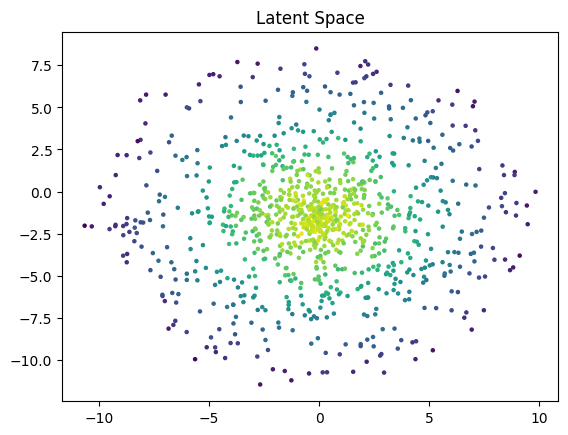

In [18]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [75]:
num = 900
J = torch.zeros((num, 2, 2))
J_trace = torch.zeros(num)
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
    J_trace[i] = torch.trace(J[i])
print(J.mean(dim=0))
print(J.std(dim=0))

J_trace = J_trace.unsqueeze(1).unsqueeze(2).repeat(1,2,2)
normed_J = J / J_trace * 2

tensor([[2.7960e-02, 4.7656e-06],
        [4.7656e-06, 2.7969e-02]])
tensor([[0.0095, 0.0020],
        [0.0020, 0.0093]])


In [ ]:
from torch.func import functional_call, jacrev, vmap

def gini(w: torch.Tensor) -> torch.Tensor:
    r"""The Gini coefficient from the `"Improving Molecular Graph Neural
    Network Explainability with Orthonormalization and Induced Sparsity"
    <https://arxiv.org/abs/2105.04854>`_ paper.

    Computes a regularization penalty :math:`\in [0, 1]` for each row of a
    matrix according to

    .. math::
        \mathcal{L}_\textrm{Gini}^i = \sum_j^n \sum_{j'}^n \frac{|w_{ij}
         - w_{ij'}|}{2 (n^2 - n)\bar{w_i}}

    and returns an average over all rows.

    Args:
        w (torch.Tensor): A two-dimensional tensor.
    """
    s = 0
    for row in w:
        t = row.repeat(row.size(0), 1)
        u = (t - t.T).abs().sum() / (2 * (row.size(-1)**2 - row.size(-1)) *
                                     row.abs().mean() + torch.finfo().eps)
        s += u
    s /= w.shape[0]
    return s

def get_batch_jacobian(func, inputs):
    params = dict(func.named_parameters())

    def fmodel(params, inputs):
        return functional_call(func, params, inputs)

    jacobians = vmap(jacrev(fmodel, argnums=(1)), in_dims=(None,0))(params, inputs)
    return jacobians

def evaluate_conformality(model, data):
    # still needs flattening for convolutions
    model.eval()
    with torch.no_grad():
        data_dim = data.shape[1]
        # latent samples
        latent = model.encode(data)
        latent_dim = latent.shape[1]

        # Compute the Jacobian of the decoder
        jacobians = get_batch_jacobian(model.decoder, latent)
        jTjs = torch.einsum('bji,bjk->bik', jacobians, jacobians)
        traces = vmap(torch.trace)(jTjs)
        lambda_factors = traces / latent.shape[1]

        # gini for diagonal elements
        diagonals = jTjs.diagonal(dim1=1, dim2=2)
        gini_value = gini(diagonals)

        # off diag mean, norm
        off_diagonal = jTjs - torch.diag_embed(diagonals)
        off_diag_mean = off_diagonal.abs().mean(dim=(1, 2))
        off_diag_norm = off_diagonal.norm(dim=(1, 2))
        off_diag_mean_normed = off_diag_mean / lambda_factors
        off_diag_norm_normed = off_diag_norm / lambda_factors

        # jTj - lambda*I mean, norm
        eye = torch.eye(jTjs.shape[1], device=jTjs.device).repeat(jTjs.shape[0], 1, 1)
        jTj_minus_lambdaI = jTjs - lambda_factors.unsqueeze(1).unsqueeze(2).repeat(1, jTjs.shape[1], jTjs.shape[1]) * eye
        jTj_minus_lambdaI_mean = jTj_minus_lambdaI.abs().mean(dim=(1, 2))
        jTj_minus_lambdaI_norm = jTj_minus_lambdaI.norm(dim=(1, 2))
        jTj_minus_lambdaI_mean_normed = jTj_minus_lambdaI_mean / lambda_factors
        jTj_minus_lambdaI_norm_normed = jTj_minus_lambdaI_norm / lambda_factors

        # determinant of jacobian vs sqrt lambda**m
        jacobian_determinants = torch.sqrt(torch.linalg.det(jTjs))
        determinant_vs_estimate = jacobian_determinants / (torch.sqrt(lambda_factors**latent_dim) + torch.finfo(torch.float32).eps)

        # std of latent space
        latent_std = latent.std(dim=0)
        
        return {
            'diagonal_gini': gini_value,
            'lambda_mean': lambda_factors.mean(),
            'lambda_std': lambda_factors.std(),
            'lambda_std_normed': lambda_factors.std() /lambda_factors.mean(),
            'off_diag_mean': off_diag_mean.mean(),
            'off_diag_norm': off_diag_norm.mean(),
            'off_diag_mean_normed': off_diag_mean_normed.mean(),
            'off_diag_norm_normed': off_diag_norm_normed.mean(),
            'jTj_minus_lambdaI_mean': jTj_minus_lambdaI_mean.mean(),
            'jTj_minus_lambdaI_norm': jTj_minus_lambdaI_norm.mean(),
            'jTj_minus_lambdaI_mean_normed': jTj_minus_lambdaI_mean_normed.mean(),
            'jTj_minus_lambdaI_norm_normed': jTj_minus_lambdaI_norm_normed.mean(),
            'determinant_vs_estimate_mean': determinant_vs_estimate.mean(),
            'determinant_vs_estimate_std': determinant_vs_estimate.std(),
            'latent_std': latent_std.mean(),
            'latent_std_max': latent_std.max(),
            'latent_std_min': latent_std.min(),
            'latent_norm': latent.norm(),
        }

In [190]:
stats = evaluate_conformality(conformal_autoencoder, data)
print("Conformality Statistics:")
for key, value in stats.items():
    print(f"{key}: {value.item():.4f}")
print("Reconstruction Error:")
print(torch.nn.MSELoss()(data, conformal_autoencoder(data)).item())

Conformality Statistics:
diagonal_gini: 0.0558
lambda_mean: 0.0279
lambda_std: 0.0092
lambda_std_normed: 0.3281
off_diag_mean: 0.0008
off_diag_norm: 0.0022
off_diag_mean_normed: 0.0293
off_diag_norm_normed: 0.0828
jTj_minus_lambdaI_mean: 0.0015
jTj_minus_lambdaI_norm: 0.0033
jTj_minus_lambdaI_mean_normed: 0.0572
jTj_minus_lambdaI_norm_normed: 0.1273
determinant_vs_estimate_mean: 0.9943
determinant_vs_estimate_std: 0.0074
latent_std: 3.6529
latent_std_max: 3.6835
latent_std_min: 3.6224
latent_norm: 169.8581
Reconstruction Error:
0.0008768265252001584


In [188]:
gini(torch.tensor([[0.0,0,0,0], [1.0,1,1,1,], [2.0,2,2,2]]))

tensor(0.)

In [132]:
eye = torch.eye(2).repeat(3, 1, 1)
print(eye)
b = torch.tensor([2.0, 3.0, 4.0]).unsqueeze(1).unsqueeze(2).repeat(1, 2, 2)
print(b)
eye * b

tensor([[[1., 0.],
         [0., 1.]],

        [[1., 0.],
         [0., 1.]],

        [[1., 0.],
         [0., 1.]]])
tensor([[[2., 2.],
         [2., 2.]],

        [[3., 3.],
         [3., 3.]],

        [[4., 4.],
         [4., 4.]]])


tensor([[[2., 0.],
         [0., 2.]],

        [[3., 0.],
         [0., 3.]],

        [[4., 0.],
         [0., 4.]]])

In [77]:
jacobians = get_batch_jacobian(decoder, encoder(data[:900]))

In [115]:
torch.diagonal(torch.tensor([[[1,2,],[3,4]], [[5,6,],[7,8]]]), dim1=1, dim2=2)

tensor([[1, 4],
        [5, 8]])

In [78]:
print(jacobians.shape)

torch.Size([900, 3, 2])


In [79]:
jTjs = torch.einsum('bji,bjk->bik', jacobians, jacobians)
traces = vmap(torch.trace)(jTjs)

In [83]:
traces.shape

torch.Size([900])

In [84]:
print(traces[-1])

tensor(0.0632, device='cuda:0', grad_fn=<SelectBackward0>)


In [85]:
J_trace[-1]

tensor([[0.0632, 0.0632],
        [0.0632, 0.0632]])

In [48]:
jacobian = []
z = encoder(data)  # shape (B, latent_dim)
y = decoder(z)
out_dim = y.shape[1]


for i in range(out_dim):
    grads = torch.autograd.grad(
        y[:, i].sum(), z, create_graph=True, retain_graph=True
    )[0]  # shape (B, in_dim)
    jacobian.append(grads.unsqueeze(1))  # shape (B, 1, in_dim)

J = torch.cat(jacobian, dim=1)

# Handle batch dimensions and reshape for matrix multiplication
if z.dim() > 1:  # Batched inputs
    J = J.flatten(start_dim=1, end_dim=-2)

In [51]:
print(J.shape)

torch.Size([99768, 3, 2])


In [91]:
def gini(w: torch.Tensor) -> torch.Tensor:
    r"""The Gini coefficient from the `"Improving Molecular Graph Neural
    Network Explainability with Orthonormalization and Induced Sparsity"
    <https://arxiv.org/abs/2105.04854>`_ paper.

    Computes a regularization penalty :math:`\in [0, 1]` for each row of a
    matrix according to

    .. math::
        \mathcal{L}_\textrm{Gini}^i = \sum_j^n \sum_{j'}^n \frac{|w_{ij}
         - w_{ij'}|}{2 (n^2 - n)\bar{w_i}}

    and returns an average over all rows.

    Args:
        w (torch.Tensor): A two-dimensional tensor.
    """
    s = 0
    for row in w:
        t = row.repeat(row.size(0), 1)
        u = (t - t.T).abs().sum() / (2 * (row.size(-1)**2 - row.size(-1)) *
                                     row.abs().mean() + torch.finfo().eps)
        s += u
    s /= w.shape[0]
    return s

In [103]:
gini_value = gini(torch.rand(3000,4))
print(gini_value)

tensor(0.3607)


In [109]:
x = torch.rand(3000, 400)
print(gini(x))
b = 0
for i in x:
    b+=gini(i.unsqueeze(0))
print(b / x.shape[0])

tensor(0.3335)
tensor(0.3335)


In [20]:
(normed_J - torch.eye(2)).abs().mean()

tensor(0.0577)

In [87]:
def gini_coefficient(x: torch.Tensor) -> torch.Tensor:
    """Compute the Gini coefficient of a 1D torch tensor."""
    if x.numel() == 0:
        return torch.tensor(0.0, dtype=x.dtype, device=x.device)
    
    x = x.flatten()
    if torch.any(x < 0):
        raise ValueError("Gini coefficient is not defined for negative values")

    # Sort
    sorted_x, _ = torch.sort(x)
    n = x.numel()
    index = torch.arange(1, n + 1, dtype=x.dtype, device=x.device)
    
    # Gini formula
    gini = (2 * torch.sum(index * sorted_x) / torch.sum(sorted_x) - (n + 1)) / n
    return gini

off_diag = normed_J.mean(dim=0) - torch.diag(normed_J.mean(dim=0))* torch.eye(2)
# how similar are the diagonal elemets?
gini = gini_coefficient(torch.diag(normed_J.mean(dim=0)))
# how big are the off-diagonal elements?
off_diag_mean = off_diag.abs().mean()
print(f"Gini Coefficient: {gini.item()}")
print(f"Off-diagonal mean: {off_diag_mean.item()}")

Gini Coefficient: 0.0005818605422973633
Off-diagonal mean: 0.0006377061363309622


In [88]:
print(gini_coefficient(torch.tensor([1, 2, 3, 4, 5])))
print(gini_coefficient(torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5])))

tensor(0.2667)
tensor(0.2667)


In [12]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/conformal_autoencoder_half_sphere.pth
Optimizer and scheduler loaded from models/conformal_autoencoder_half_sphere_optimizer.pth
